Definition of the absorption optical depth:
$$
\tau = log({I_0 \over I})
$$

Definition of the absorption Angstrom exponent:
$$
AAE = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import ISSWlib as IS
import pandas as pd
import os

In [2]:
%matplotlib inline

In [3]:
pwd

'/home/chemistry/LAI_in_snow/ISSW'

In [4]:
# Choose the spectrum folder and load in the list of spectra there
# spectrum_folder = 'Rainier_and_MtCook_comparison/'
# spectrum_folder = 'UPS_Rainier2025-07-03-01/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder_Rainier/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder_Baker/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder_Adams/'; filtertype = 'millipore'
# spectrum_folder = 'UCBoulder_Misc/'; filtertype = 'millipore'
# spectrum_folder = 'UPS_2016Chile/'; filtertype = 'nucleopore'
# spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'
# spectrum_folder = 'UPS_INKStandards/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucInc/'; filtertype = 'nucleopore'
# spectrum_folder = '2026July7/NucFul/'; filtertype = 'nucleopore'
spectrum_folder = 'NuCStandards/'; filtertype = 'nucleopore'

# !ls -l '2026July7'
# !ls -l '2026July7/NucFul'
# !ls -l '2026July7/NucInc'

In [5]:
# Checking location of files
files = os.listdir(spectrum_folder)
print(files)

['NuC15.txt', 'NuC1.txt', 'NuC3.txt', '.ipynb_checkpoints', 'Blank.txt', 'NuC6.txt', 'NuC13.txt', 'NuC10.txt', 'spectrum_files.txt']


In [6]:
# Parameter file
# parameter_filename = 'calibration parameters from UPS_INKStandards (July 13, 2026).csv'
parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
df = pd.read_csv(parameter_filename)
print(df)
LRF = df.at[0, 'LRF']
R1R2_1 = df.at[0,'R1R2_1']
R1R2_2 = df.at[0,'R1R2_2']
beta1_std = df.at[0,'beta1_std']
beta2_std = df.at[0,'beta2_std']
AAE_std = df.at[0,'AAE_std']
LAHM_factor = df.at[0,'LAHM_factor']

            Standard       LRF    R1R2_1   R1R2_2  beta1_std  beta2_std  \
0  2026July7/NucFul/  0.110101  0.808194  0.83495        8.9   6.504393   

   AAE_std  LAHM_factor  
0     1.09     0.463158  


In [7]:
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  NuCStandards/spectrum_files.txt , finding these spectra:
      NuC1.txt
      NuC3.txt
      NuC6.txt
      NuC10.txt
      NuC13.txt
      NuC15.txt


In [8]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

lambda_450 =  450.0
lambda_600 =  600.0


In [9]:
# Preallocate arrays and other constants
chi_observed = np.zeros((number_of_loadings,2))
bot = np.log(lambda_nm[I_1]/lambda_nm[I_2])

chi1, chi2 =  0.04166678717362258 0.026974067431267294
chi1, chi2 =  0.05702673808666225 0.03964816365919684
chi1, chi2 =  0.16150855276316206 0.133415695350176
chi1, chi2 =  0.6161871000429123 0.5583302356554586
chi1, chi2 =  1.1343547693700478 1.0254280654116172
chi1, chi2 =  1.439635096918916 1.2904964804458396


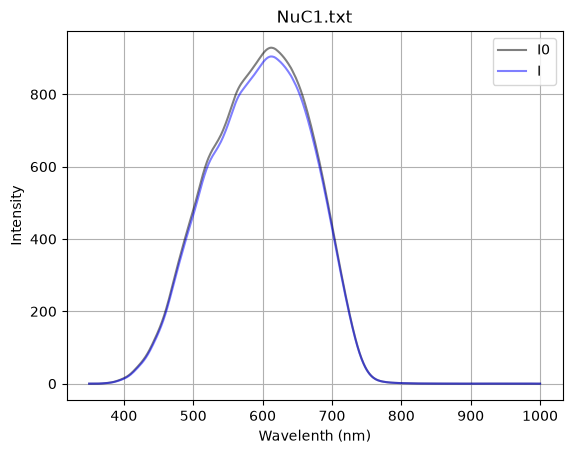

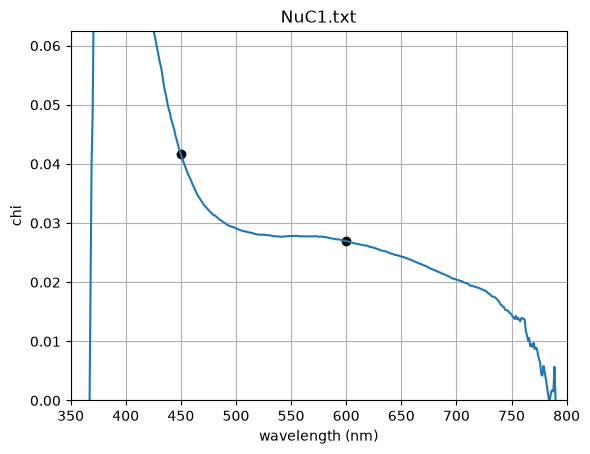

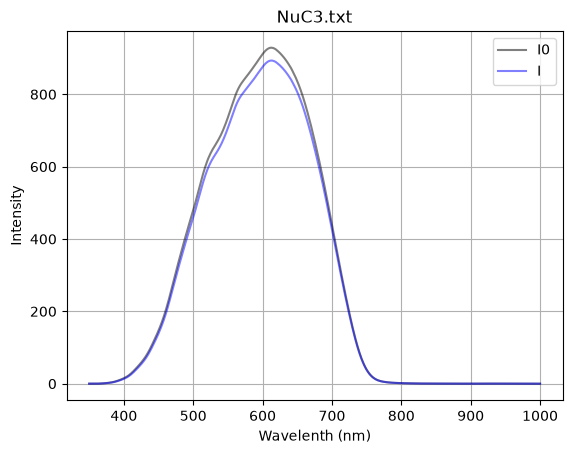

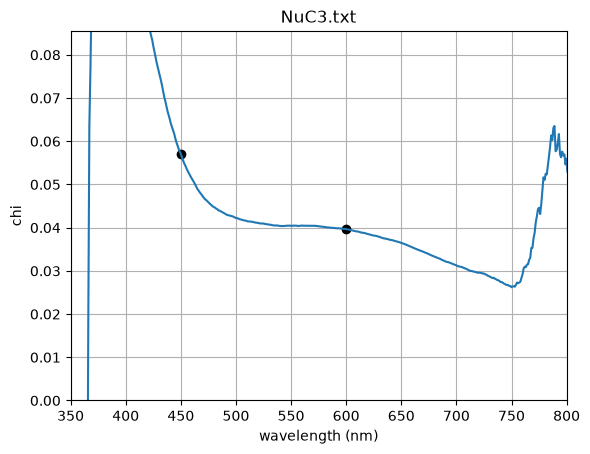

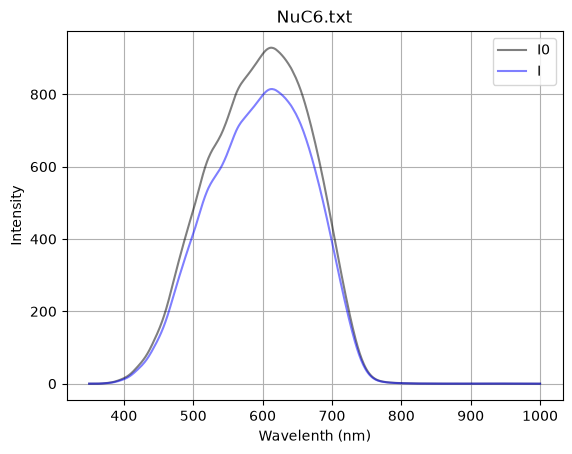

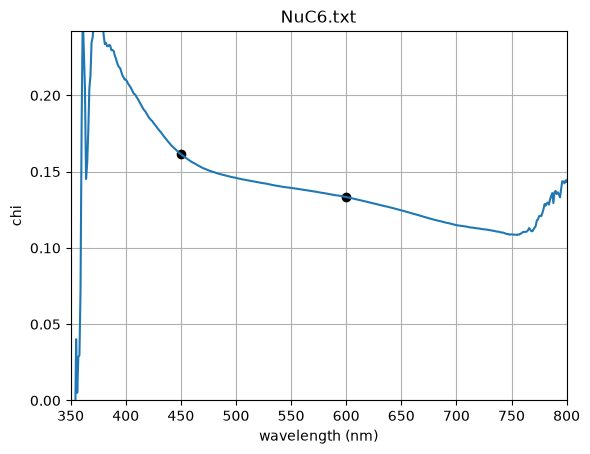

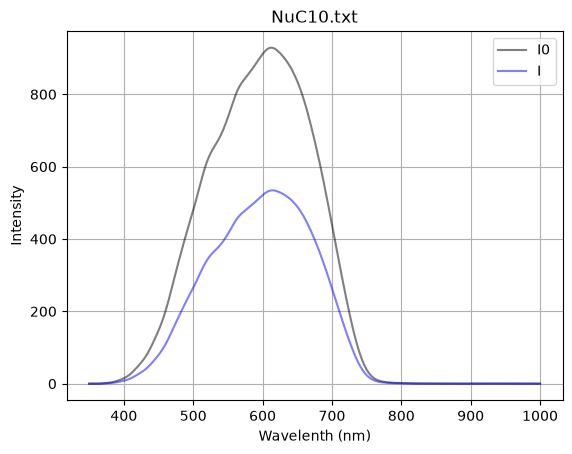

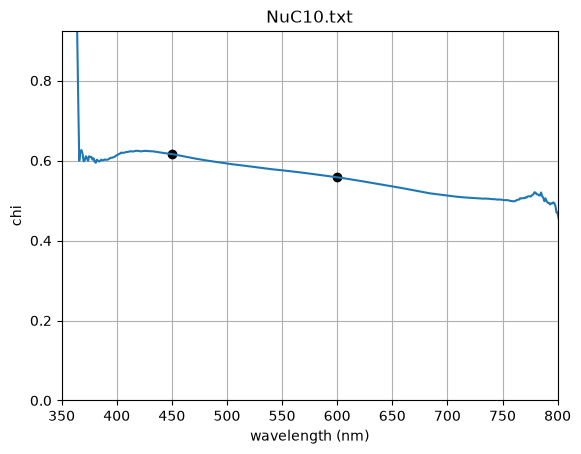

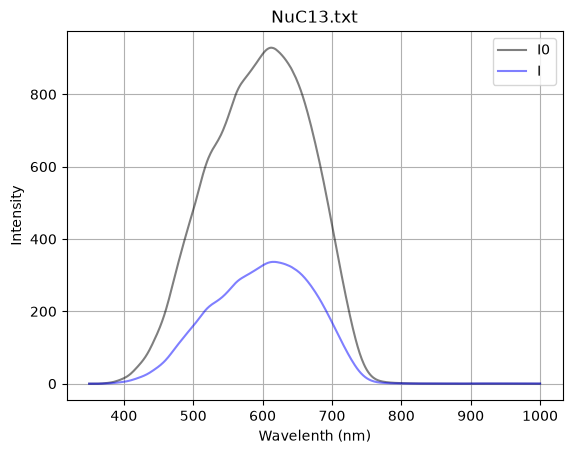

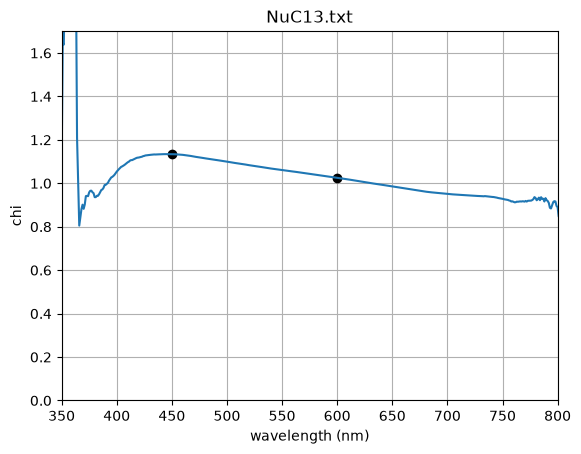

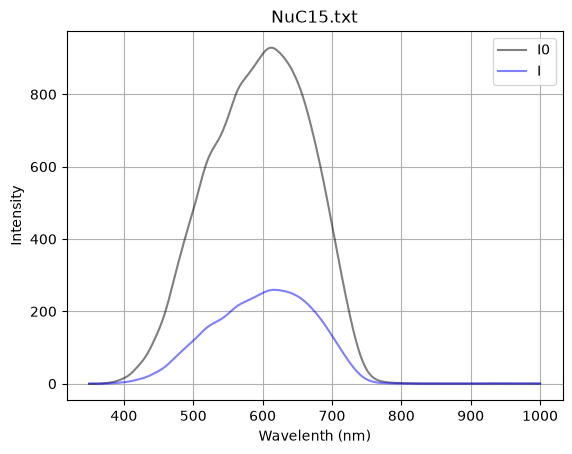

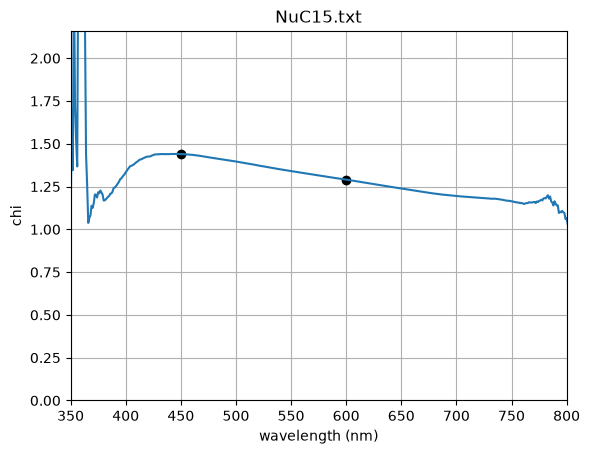

In [10]:
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get the observed chi-values
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    print('chi1, chi2 = ', chi[I_1],chi[I_2])
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]
    
    # Get the tau values associated with these two points
    tau_1 = IS.invert_chi_theory(chi[I_1],R1R2_1)
    tau_2 = IS.invert_chi_theory(chi[I_2],R1R2_2)
    
    # Get the Angstrom exponent
    top = np.log(tau_1/tau_2)
    AAE = -top/bot
    
    # Record for plotting later
    if i==0:
        AAElist = AAE
        Ilist = I
        tau_1list = tau_1
        tau_2list = tau_2
    else:
        AAElist = np.append(AAElist,AAE)
        Ilist = np.vstack((Ilist,I))
        tau_1list = np.append(tau_1list,tau_1)
        tau_2list = np.append(tau_2list,tau_2)

In [11]:
# Getting equivalent loadings
L_1list = tau_1list/(LRF*beta1_std/100)
L_2list = tau_2list/(LRF*beta2_std/100)

# Reporting
print('Loadings and AAE, nucleopore')
for i in range(number_of_loadings):
    print('For ',spectrum_list[i],', L1 =', L_1list[i],', L2 =', L_2list[i],', AAE =', AAElist[i])


# Adjusting for the filter type; if it's LAHM, the units become ug (instead of ug/cm^2)
if filtertype == 'millipore':
    print('')
    print('Applying the millipore filter correction ...')
    L_1list_LAHM = L_1list*LAHM_factor
    L_2list_LAHM = L_2list*LAHM_factor

    # Reporting
    print('Loadings and AAE, millipore')
    for i in range(number_of_loadings):
        print('For ',spectrum_list[i],', L1 =', L_1list_LAHM[i],', L2 =', L_2list_LAHM[i],', AAE =', AAElist[i])

Loadings and AAE, nucleopore
For  NuC1.txt , L1 = 0.2302341667304921 , L2 = 0.17168493005018098 , AAE = 2.110000689422577
For  NuC3.txt , L1 = 0.31752678608281726 , L2 = 0.2539526255778579 , AAE = 1.8666019006173984
For  NuC6.txt , L1 = 0.9477458936591361 , L2 = 0.8957794158149589 , AAE = 1.286022735172281
For  NuC10.txt , L1 = 4.582734913273779 , L2 = 4.678319304946438 , AAE = 1.0182438428112692
For  NuC13.txt , L1 = 11.195239573443102 , L2 = 11.104094853638427 , AAE = 1.1184157569123485
For  NuC15.txt , L1 = 16.820905416043356 , L2 = 16.228447898751387 , AAE = 1.2146401528933808
